<a href="https://colab.research.google.com/github/risyadksm/PCVK_GANJIL_2025/blob/main/QUIZ1_PCVK_SOAL_NO_3.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [2]:
import cv2
import numpy as np
import matplotlib.pyplot as plt
from scipy.ndimage import gaussian_filter, median_filter
from skimage.metrics import structural_similarity as ssim
from google.colab import files


Silakan upload gambar A.jpg dan B.jpg


Saving A.jpg to A.jpg
Saving B.png to B.png


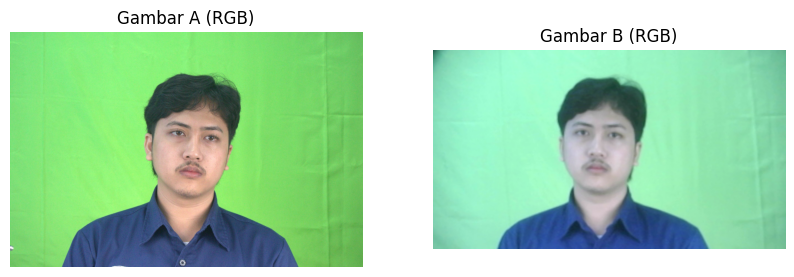

In [3]:
plt.rcParams['figure.figsize'] = (12, 6)
print("\nSilakan upload gambar A.jpg dan B.jpg")
uploaded = files.upload()

# Simpan file yang diupload
for filename in uploaded.keys():
    if 'A' in filename or 'a' in filename:
        with open('A.jpg', 'wb') as f:
            f.write(uploaded[filename])
    elif 'B' in filename or 'b' in filename:
        with open('B.jpg', 'wb') as f:
            f.write(uploaded[filename])

# Load gambar
img_a = cv2.imread('A.jpg')
img_b = cv2.imread('B.jpg')

# Convert BGR ke RGB untuk matplotlib
img_a_rgb = cv2.cvtColor(img_a, cv2.COLOR_BGR2RGB)
img_b_rgb = cv2.cvtColor(img_b, cv2.COLOR_BGR2RGB)

# Convert ke grayscale
gray_a = cv2.cvtColor(img_a_rgb, cv2.COLOR_RGB2GRAY)
gray_b = cv2.cvtColor(img_b_rgb, cv2.COLOR_RGB2GRAY)

# ==== Tampilkan hasil upload ====
plt.figure(figsize=(10, 5))

plt.subplot(1, 2, 1)
plt.imshow(img_a_rgb)
plt.title("Gambar A (RGB)")
plt.axis("off")

plt.subplot(1, 2, 2)
plt.imshow(img_b_rgb)
plt.title("Gambar B (RGB)")
plt.axis("off")

plt.show()

Gambar A - Shape: (854, 1280, 3), Type: uint8
Gambar B - Shape: (360, 640, 3), Type: uint8

Statistik Gambar A:
  Mean: 162.79
  Std: 44.67
  Min: 13
  Max: 255

Statistik Gambar B:
  Mean: 182.06
  Std: 47.22
  Min: 32
  Max: 224


(np.float64(-0.5), np.float64(639.5), np.float64(359.5), np.float64(-0.5))

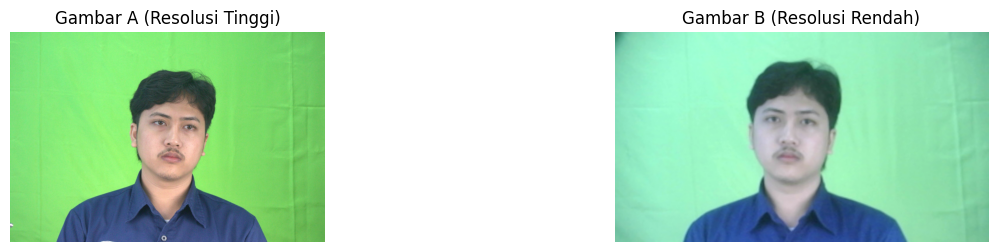

In [9]:
print(f"Gambar A - Shape: {img_a_rgb.shape}, Type: {img_a_rgb.dtype}")
print(f"Gambar B - Shape: {img_b_rgb.shape}, Type: {img_b_rgb.dtype}")

# Hitung statistik grayscale
stats_a = {
    "Mean": np.mean(gray_a),
    "Std": np.std(gray_a),
    "Min": np.min(gray_a),
    "Max": np.max(gray_a),
}

stats_b = {
    "Mean": np.mean(gray_b),
    "Std": np.std(gray_b),
    "Min": np.min(gray_b),
    "Max": np.max(gray_b),
}

# Cetak statistik
print("\nStatistik Gambar A:")
for k, v in stats_a.items():
    print(f"  {k}: {v:.2f}" if isinstance(v, float) else f"  {k}: {v}")

print("\nStatistik Gambar B:")
for k, v in stats_b.items():
    print(f"  {k}: {v:.2f}" if isinstance(v, float) else f"  {k}: {v}")

# === Plot gambar + statistik ===
plt.figure(figsize=(15, 6))

# Plot gambar
plt.subplot(2, 2, 1)
plt.imshow(img_a_rgb)
plt.title('Gambar A (Resolusi Tinggi)', fontsize=12)
plt.axis('off')

plt.subplot(2, 2, 2)
plt.imshow(img_b_rgb)
plt.title('Gambar B (Resolusi Rendah)', fontsize=12)
plt.axis('off')


a. Perbandingan Histogram Citra A (resolusi tinggi) dan B (resolusi rendah):


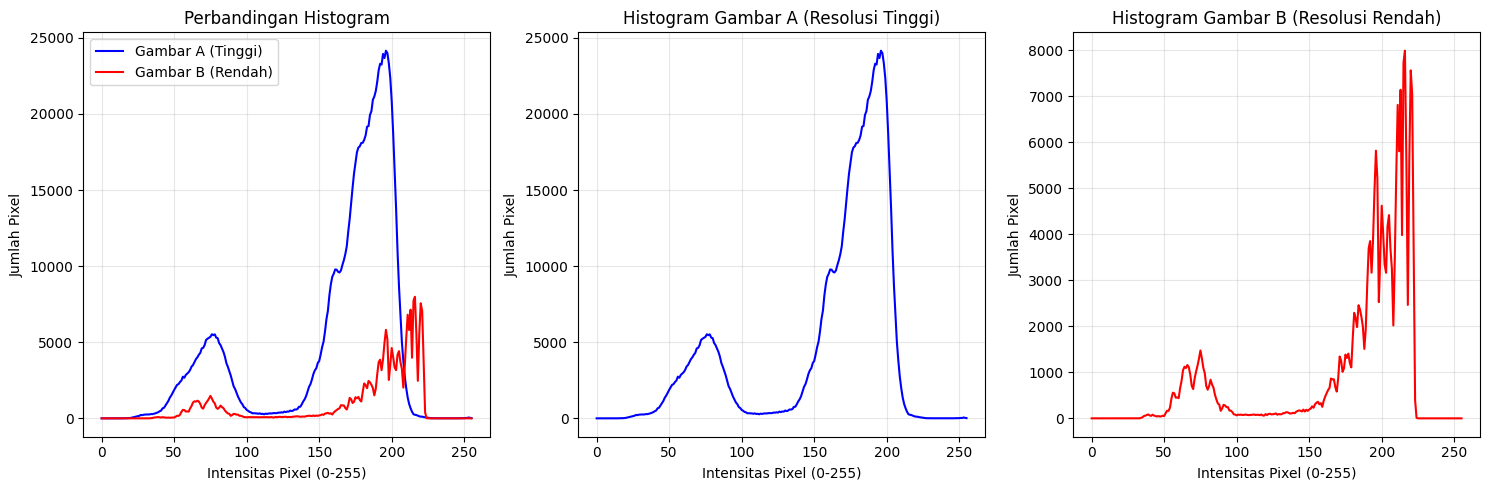


b. Analisis Distribusi Intensitas:


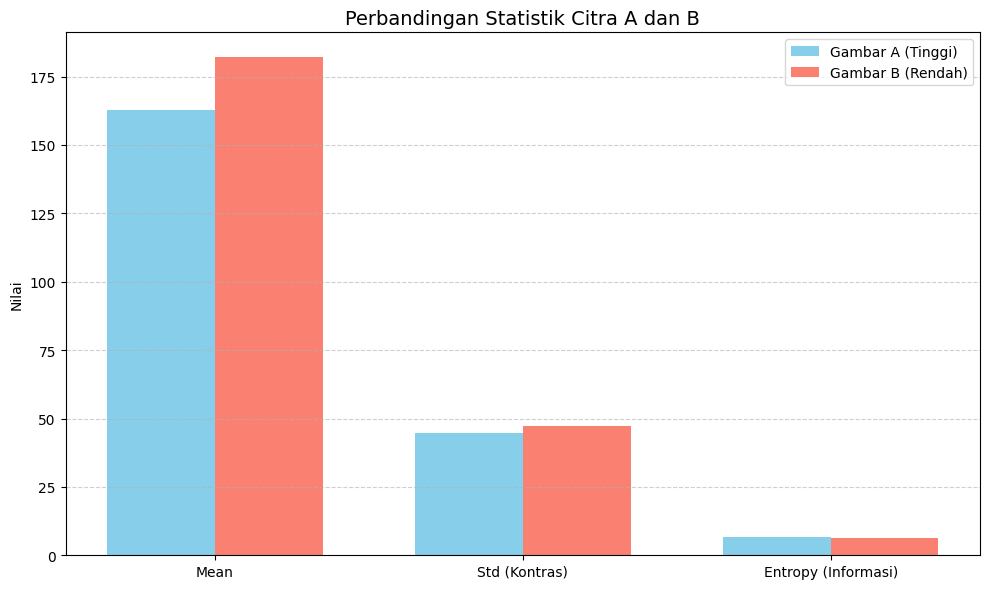

In [10]:
# a. Bandingkan histogram citra A dan B
print("a. Perbandingan Histogram Citra A (resolusi tinggi) dan B (resolusi rendah):")

hist_a = cv2.calcHist([gray_a], [0], None, [256], [0, 256])
hist_b = cv2.calcHist([gray_b], [0], None, [256], [0, 256])

plt.figure(figsize=(15, 5))

# Histogram gabungan
plt.subplot(1, 3, 1)
plt.plot(hist_a, color='blue', label='Gambar A (Tinggi)')
plt.plot(hist_b, color='red', label='Gambar B (Rendah)')
plt.title('Perbandingan Histogram')
plt.xlabel('Intensitas Pixel (0-255)')
plt.ylabel('Jumlah Pixel')
plt.legend()
plt.grid(True, alpha=0.3)

# Histogram A
plt.subplot(1, 3, 2)
plt.plot(hist_a, color='blue')
plt.title('Histogram Gambar A (Resolusi Tinggi)')
plt.xlabel('Intensitas Pixel (0-255)')
plt.ylabel('Jumlah Pixel')
plt.grid(True, alpha=0.3)

# Histogram B
plt.subplot(1, 3, 3)
plt.plot(hist_b, color='red')
plt.title('Histogram Gambar B (Resolusi Rendah)')
plt.xlabel('Intensitas Pixel (0-255)')
plt.ylabel('Jumlah Pixel')
plt.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

# b. Analisis distribusi intensitas
print("\nb. Analisis Distribusi Intensitas:")

# Hitung entropy
hist_a_norm = hist_a / np.sum(hist_a)
hist_b_norm = hist_b / np.sum(hist_b)
entropy_a = -np.sum(hist_a_norm * np.log2(hist_a_norm + 1e-10))
entropy_b = -np.sum(hist_b_norm * np.log2(hist_b_norm + 1e-10))

# Statistik mean & std
mean_a, std_a = np.mean(gray_a), np.std(gray_a)
mean_b, std_b = np.mean(gray_b), np.std(gray_b)

# --- Bar Chart Perbandingan Statistik ---

labels = ["Mean", "Std (Kontras)", "Entropy (Informasi)"]
values_a = [mean_a, std_a, entropy_a]
values_b = [mean_b, std_b, entropy_b]

x = np.arange(len(labels))  # posisi label
width = 0.35  # lebar bar

plt.figure(figsize=(10, 6))
plt.bar(x - width/2, values_a, width, label="Gambar A (Tinggi)", color="skyblue")
plt.bar(x + width/2, values_b, width, label="Gambar B (Rendah)", color="salmon")

plt.xticks(x, labels)
plt.ylabel("Nilai")
plt.title("Perbandingan Statistik Citra A dan B", fontsize=14)
plt.legend()
plt.grid(axis='y', linestyle='--', alpha=0.6)

plt.tight_layout()
plt.show()



3. PENINGKATAN KUALITAS (ENHANCEMENT)

a. Peningkatan kualitas citra B menggunakan Contrast Stretching dan CLAHE:



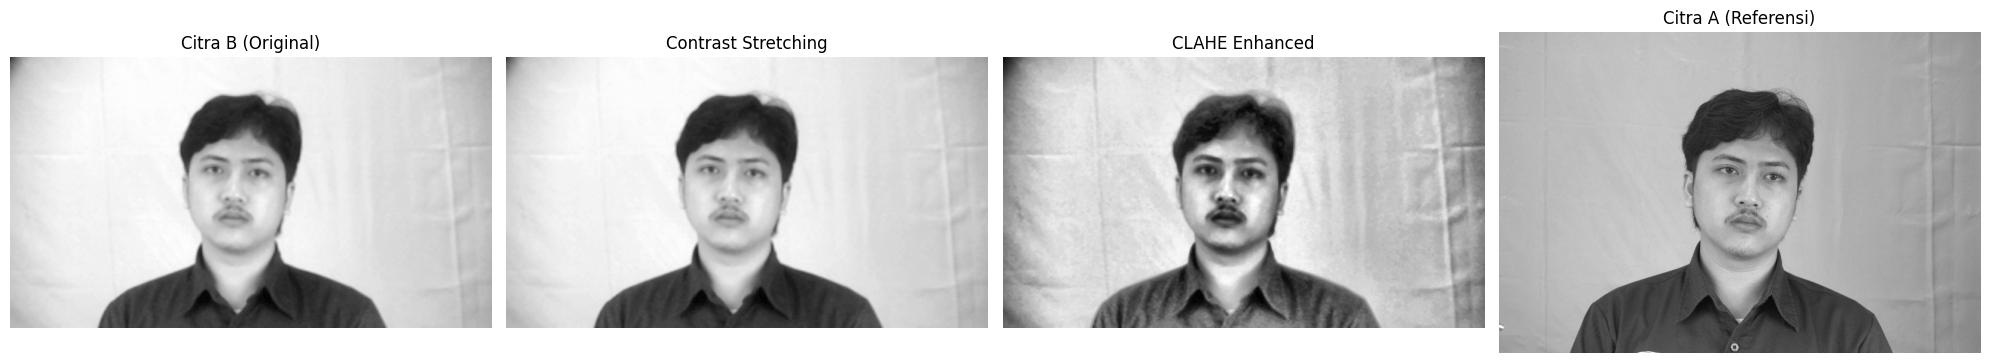

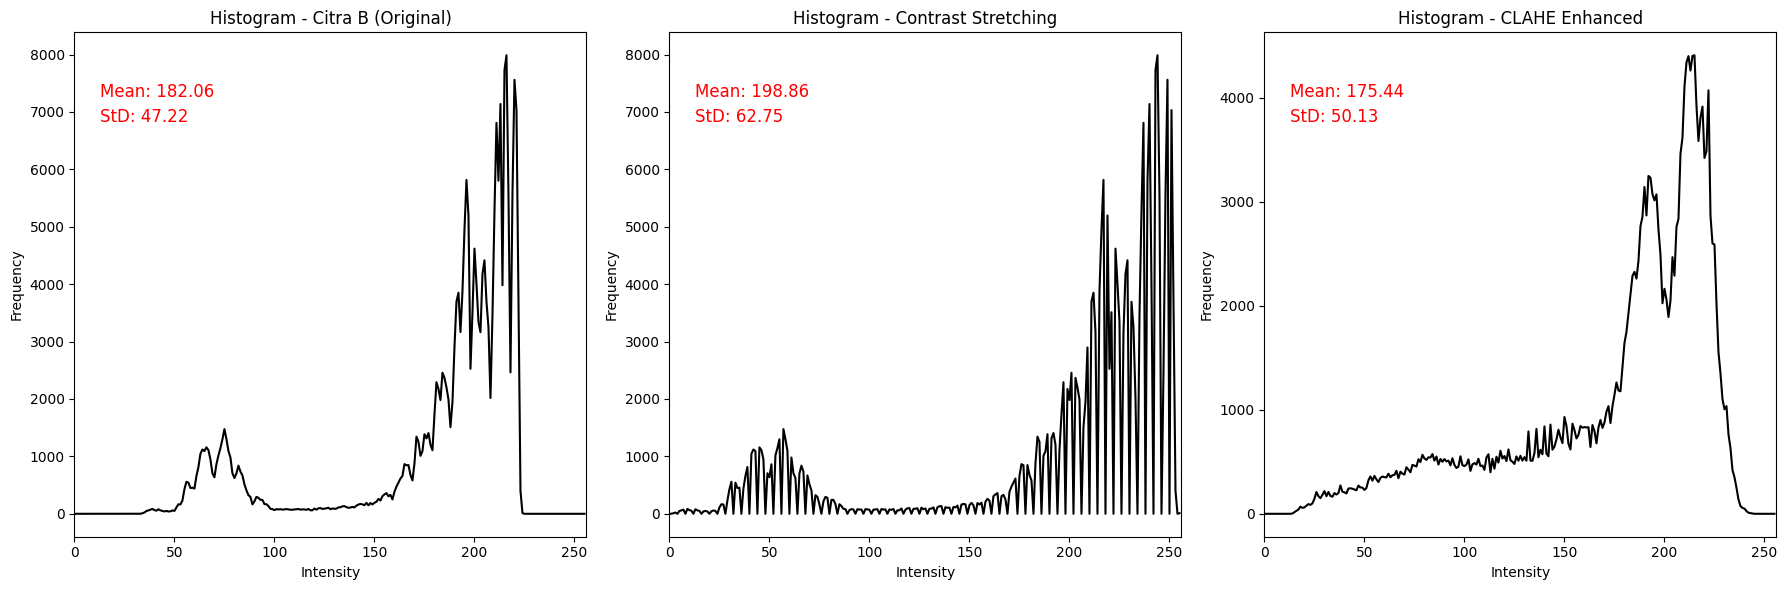

b. Evaluasi efektivitas metode:


   Contrast Stretching:
     - SSIM (kemiripan dengan referensi): 0.6893
     - Kontras meningkat dari 47.22 → 62.75

   CLAHE:
     - SSIM (kemiripan dengan referensi): 0.5913
     - Kontras meningkat dari 47.22 → 50.13

KESIMPULAN:
  Contrast Stretching lebih efektif (SSIM lebih tinggi: 0.6893 > 0.5913)
  Contrast Stretching lebih mendekati referensi, walaupun peningkatan detail tidak sebanyak CLAHE.


In [36]:
print("3. PENINGKATAN KUALITAS (ENHANCEMENT)\n")
print("="*60)

# a. Terapkan Contrast Stretching dan CLAHE pada citra B
print("a. Peningkatan kualitas citra B menggunakan Contrast Stretching dan CLAHE:\n")

# Contrast Stretching
min_val = np.min(gray_b)
max_val = np.max(gray_b)
contrast_stretched = ((gray_b - min_val) / (max_val - min_val) * 255).astype(np.uint8)

# CLAHE
clahe = cv2.createCLAHE(clipLimit=3.0, tileGridSize=(8,8))
clahe_enhanced = clahe.apply(gray_b)

# Hitung statistik dasar
mean_original = np.mean(gray_b)
std_original = np.std(gray_b)
mean_cs = np.mean(contrast_stretched)
std_cs = np.std(contrast_stretched)
mean_clahe = np.mean(clahe_enhanced)
std_clahe = np.std(clahe_enhanced)

# Samakan ukuran dengan referensi
if gray_b.shape != gray_a.shape:
    gray_a_resized = cv2.resize(gray_a, (gray_b.shape[1], gray_b.shape[0]))
else:
    gray_a_resized = gray_a

# Hitung SSIM (kemiripan dengan citra referensi A)
ssim_cs = ssim(contrast_stretched, gray_a_resized, data_range=255)
ssim_clahe = ssim(clahe_enhanced, gray_a_resized, data_range=255)

# --- Visualisasi hasil ---
plt.figure(figsize=(20, 6))

# Citra B (Original)
plt.subplot(1, 4, 1)
plt.imshow(gray_b, cmap='gray')
plt.title('Citra B (Original)')
plt.axis('off')
plt.xlabel(f"Mean: {mean_original:.2f}, StD: {std_original:.2f}", fontsize=10, color='red')

# Contrast Stretching
plt.subplot(1, 4, 2)
plt.imshow(contrast_stretched, cmap='gray')
plt.title('Contrast Stretching')
plt.axis('off')
plt.xlabel(f"SSIM: {ssim_cs:.4f}\nKontras: {std_original:.2f} → {std_cs:.2f}",
           fontsize=10, color='red')

# CLAHE Enhanced
plt.subplot(1, 4, 3)
plt.imshow(clahe_enhanced, cmap='gray')
plt.title('CLAHE Enhanced')
plt.axis('off')
plt.xlabel(f"SSIM: {ssim_clahe:.4f}\nKontras: {std_original:.2f} → {std_clahe:.2f}",
           fontsize=10, color='red')

# Citra A (Referensi)
plt.subplot(1, 4, 4)
plt.imshow(gray_a, cmap='gray')
plt.title('Citra A (Referensi)')
plt.axis('off')

plt.tight_layout()
plt.show()

# --- Analisis Histogram dan Statistik ---
def plot_histogram(image, ax, title, mean, std_dev):
    # Hitung histogram
    hist = cv2.calcHist([image], [0], None, [256], [0, 256])
    ax.plot(hist, color='black')
    ax.set_title(title)
    ax.set_xlim(0, 256)
    ax.set_xlabel('Intensity')
    ax.set_ylabel('Frequency')

    # Info statistik di pojok atas
    ax.text(0.05, 0.9, f'Mean: {mean:.2f}', transform=ax.transAxes,
            color='red', fontsize=12, verticalalignment='top')
    ax.text(0.05, 0.85, f'StD: {std_dev:.2f}', transform=ax.transAxes,
            color='red', fontsize=12, verticalalignment='top')

# Plot histograms
fig, axes = plt.subplots(1, 3, figsize=(18, 6))

plot_histogram(gray_b, axes[0], 'Histogram - Citra B (Original)', mean_original, std_original)
plot_histogram(contrast_stretched, axes[1], 'Histogram - Contrast Stretching', mean_cs, std_cs)
plot_histogram(clahe_enhanced, axes[2], 'Histogram - CLAHE Enhanced', mean_clahe, std_clahe)

plt.tight_layout()
plt.show()

# --- Evaluasi efektivitas metode ---
print("b. Evaluasi efektivitas metode:\n")

print(f"\n   Contrast Stretching:")
print(f"     - SSIM (kemiripan dengan referensi): {ssim_cs:.4f}")
print(f"     - Kontras meningkat dari {std_original:.2f} → {std_cs:.2f}")

print(f"\n   CLAHE:")
print(f"     - SSIM (kemiripan dengan referensi): {ssim_clahe:.4f}")
print(f"     - Kontras meningkat dari {std_original:.2f} → {std_clahe:.2f}")

# Kesimpulan lebih jelas
print("\nKESIMPULAN:")
if ssim_clahe > ssim_cs:
    print(f"  CLAHE lebih efektif (SSIM lebih tinggi: {ssim_clahe:.4f} > {ssim_cs:.4f})")
    print("   CLAHE memberikan distribusi intensitas lebih merata, sehingga detail gambar lebih jelas.")
else:
    print(f"  Contrast Stretching lebih efektif (SSIM lebih tinggi: {ssim_cs:.4f} > {ssim_clahe:.4f})")
    print("  Contrast Stretching lebih mendekati referensi, walaupun peningkatan detail tidak sebanyak CLAHE.")


4. DENOISING & EVALUASI KUALITAS

a. Menambahkan Gaussian Noise dan menerapkan filtering...



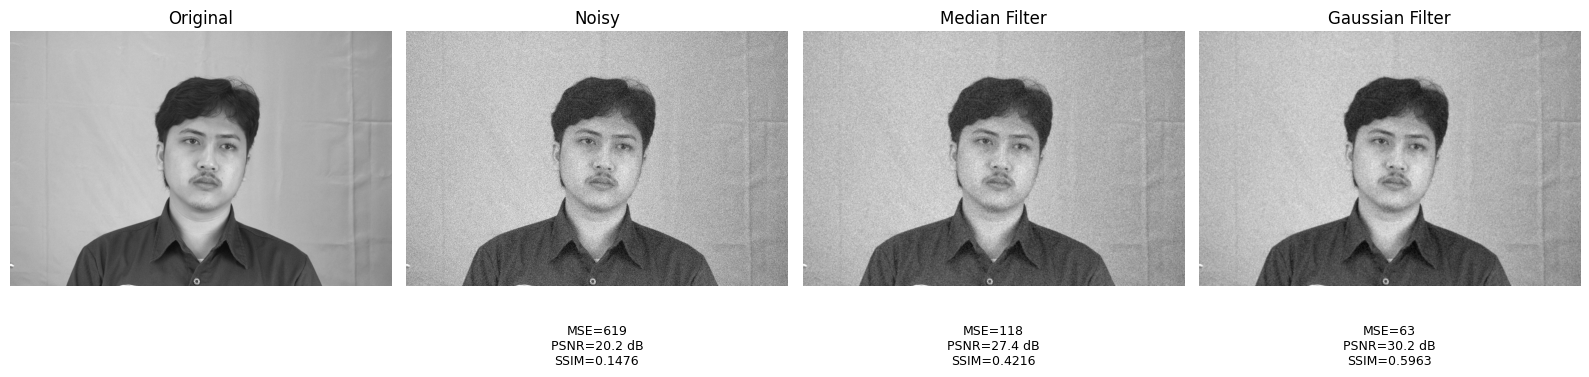


c. Kesimpulan:
   Filter terbaik: Gaussian (PSNR=30.19 dB, SSIM=0.5972)


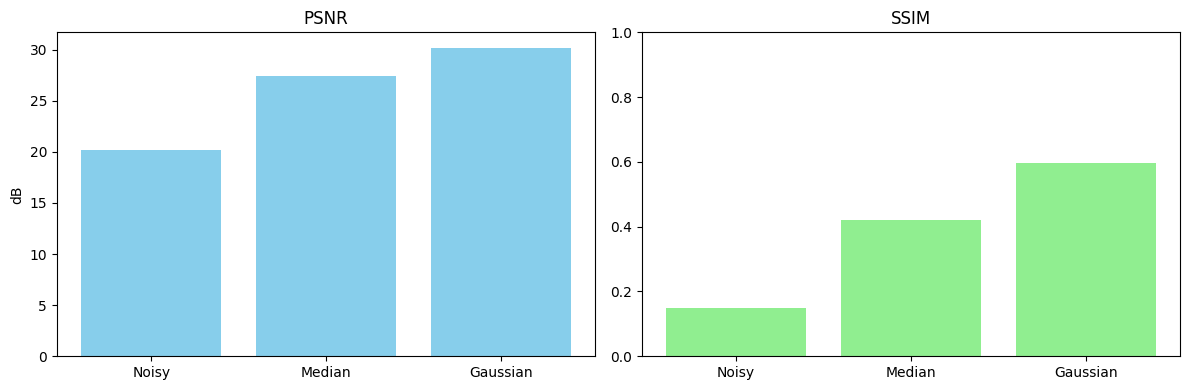

In [37]:
print("4. DENOISING & EVALUASI KUALITAS\n")
print("="*60)

# a. Tambahkan Gaussian Noise pada citra A
print("a. Menambahkan Gaussian Noise dan menerapkan filtering...\n")

# Tambahkan noise Gaussian
noise = np.random.normal(0, 25, gray_a.shape)
noisy = np.clip(gray_a + noise, 0, 255).astype(np.uint8)

# Terapkan median dan gaussian filter
median = median_filter(noisy, size=3)
gaussian = np.clip(gaussian_filter(noisy.astype(np.float32), sigma=1), 0, 255).astype(np.uint8)

# Tampilkan hasil
titles = ['Original', 'Noisy', 'Median Filter', 'Gaussian Filter']
images = [gray_a, noisy, median, gaussian]

plt.figure(figsize=(16, 4.5))
for i in range(4):
    plt.subplot(1, 4, i + 1)
    plt.imshow(images[i], cmap='gray')
    plt.title(titles[i])
    plt.axis('off')

    # Tambahkan teks evaluasi di bawah gambar (jika ada)
    if evals[i]:
        plt.text(0.5, -0.15, evals[i], ha='center', va='top', transform=plt.gca().transAxes, fontsize=9)

plt.tight_layout()
plt.show()

# c. Tentukan filter terbaik (berdasarkan PSNR dan SSIM)
print("\nc. Kesimpulan:")
best = max(metrics.items(), key=lambda x: (x[1][1], x[1][2]))  # Prioritaskan PSNR lalu SSIM
print(f"   Filter terbaik: {best[0]} (PSNR={best[1][1]:.2f} dB, SSIM={best[1][2]:.4f})")

# Visualisasi metrik
labels = list(metrics.keys())
psnr_vals = [v[1] for v in metrics.values()]
ssim_vals = [v[2] for v in metrics.values()]

plt.figure(figsize=(12, 4))

plt.subplot(1, 2, 1)
plt.bar(labels, psnr_vals, color='skyblue')
plt.title('PSNR')
plt.ylabel('dB')

plt.subplot(1, 2, 2)
plt.bar(labels, ssim_vals, color='lightgreen')
plt.title('SSIM')
plt.ylim(0, 1)

plt.tight_layout()
plt.show()
